## Star Formation Notes
Some notes as I learn about Star formation, especially the codes involved.<br>
This is very informal and changes constantly as I learn new things.

This comes from a Jupyterlab notebook. The notebook is available at: <br>
https://github.com/richardskg/StarFormation/blob/main/starformation.ipynb <br>
There should be a download button in the upper right when you follow the link, or you can clone the repo.<br>
If you are running the notebook and there are missing images or video, you can get it from the same repo that has this notebook. Just download it and put it alongside the notebook file. If you clone the repo, you will then get all images/videos as they are added by simply pulling the latest code.

There is also a jupyterlite version that runs entirely in the browser. It is available at: <br>
https://nephinumerics.com/jupyterlite/

## Contents:
0. Python code definitions
1. Intro
2. SPH
3. Other Meshless Codes (GIZMO)
4. Formation theory
5. References

## 0. Useful code definitions

In [1]:
%pip install -q plotly numpy pandas nbformat>=4.2.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Here are some definitions and functions that will make it possible to create the plots that we want.
# For now we will use 1-D only. That may change in the future.
# This is literal, simplistic code with no attempt at optimiziation.
# When used for a simulation with many particles, it will be necessary to use a tree to know which particles
# are neighbors of the current particle to reduce the time in the sums.
import numpy as np

# ---------------------------------------------------------
# Create the particle list with positions and masses. Initially the densities will be 1.0
# and we then calculate the density from the masses and positions.
# The particles will be evenly spaced and of equal mass.class particles:
class particles:
    # h_factor is the (real) number of grid points in h (h = (max-min) * h_factor/numParticles
    def __init__(self, h_factor):
        self.ndim = 1
        self.num_particles = 11
        self.min_x = 0.0
        self.max_x = 1.0
        self.x = np.linspace(self.min_x,self.max_x,self.num_particles)
        self.mass = 0.02 + 0*self.x # This gives us a uniform mass of 0.02, and the same size list as x
        self.h = (self.max_x - self.min_x)*h_factor/(self.num_particles-1) + 0*self.x # make h the distance between particles * h_factor.
        self.density = 0.0 + 0*self.x # Start with a density of 0, we calculate the actual density from the mass next.
        self.update_density()

    def update_density(self):
        for i, ri in enumerate(self.x):
            self.density[i] = 0.0 # start with 0 and sum:
            # ri = self.x[i]
            hi = self.h[i]
            for j, rj in enumerate(self.x):
                r = abs(ri - rj)
                self.density[i] += self.mass[j]*kernel_sph(r, hi)

# ---------------------------------------------------------
# These particles will have a gaussian position distribution but still have constant mass.
def create_particles_gaussian():
    N_1D=32; # 1D particle number (so total particle number is N_1D^DIMS)
    x0=np.arange(-0.5,0.5,1./N_1D); x0+=0.5*(0.5-x0[-1]);
    
      

# ---------------------------------------------------------
# Define the spline kernel
def kernel_sph(r,h):
    v = abs(r/h)
    retVal = 0.0
    leading_factor = 2.0/(3.0*h)
    if (v >= 0 and v < 1):
        retVal =  1.0 - 1.5*v*v + 0.75*v**3
    elif (v >= 1 and v < 2):
        retVal = 0.25*(2.0-v)**3

    return retVal*leading_factor

# ---------------------------------------------------------
# Given a list of particles with their positions, masses, densities 
# and given a function to smooth at a given r, return the smoothed function at r.
# See "Kernel Smoothing" below for the equation.
def smooth(particles, func, r_in):
    fr = 0 # func(r)
    for mass, dens, rj, hj in zip(particles.mass, particles.density, particles.x, particles.h):
        r = abs(r_in - rj)
        fr += mass*func(rj)*kernel_sph(r, hj)/dens

    return fr

def omega_calc(x, parts):
    h = parts.h[0] # this should be h(x), but we'll use h(x_0). Only really works if h is constant.
    omega = 0.001 # start with a small non-zero amount so we don't divide by 0
    for j, xj in enumerate(parts.x):
        omega += kernel_sph(x-xj, h)
    # print(f"omega({x-xj}) = {omega}")
    return omega
    
def psi_calc(x, parts, index):
    h = parts.h[0] # this should be h(x), but we'll use h(x_0). Only really works if h is constant.
    xi = parts.x[index]
    psi = kernel_sph(x-xi, h)/omega_calc(x, parts)
    return psi
    


# Tests to make sure I'm on the right track as I code:
# x = 0.
# h = .5
# print(f"kernel_sph({x,h}) = {kernel_sph(x,h)}")

# x = 0.1
# print(f"kernel_sph({x,h}) = {kernel_sph(x,h)}")

# x = 0.9
# print(f"kernel_sph({x,h}) = {kernel_sph(x,h)}")

# x = -2.1
# print(f"kernel_sph({x,h}) = {kernel_sph(x,h)}")

# parts = particles(1)
# print(f"particles().x, .h = {parts.x, parts.h} ")
# print(f"particles().x, .mass, .dens = {parts.x, parts.mass, parts.density} ")

# num_r = 70
# test_r = np.linspace(parts.min_x,parts.max_x, num_r)
# test_f = 0.0 + 0.0*test_r
# for i, r in enumerate(test_r):
#     test_f[i] = smooth(parts, uniform_func, r)

# print(f"test_f: {test_f}")

        
    

In [3]:
# Here are the functions to plot the density and a smoothed function to allow investigation of how the kernel works.
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

def plot_spline_info(h_factor, func_choice, num_r):
    def uniform_func(r):
        if func_choice == 'uniform':
            return 1.0
        elif func_choice == 'sin':
            return np.sin(2.*np.pi*r)
        else:
            return 0.
    
    # First plot the density and a smoothed function
    p = particles(h_factor)
    # num_r = 19
    test_r = np.linspace(p.min_x,p.max_x, num_r)
    test_f = 0.0 + 0.0*test_r
    for i, r in enumerate(test_r):
        test_f[i] = smooth(p, uniform_func, r)
    
    # Get the function at the particles positions so we can see where the particles are on the smoothed function plot.
    test_r_points = 0.0 + p.x
    test_f_points = 0.0 + 0.0*test_r_points
    for i, r in enumerate(test_r_points):
        test_f_points[i] = smooth(p, uniform_func, r)
    
    fig10 = px.scatter(x=p.x, y=test_f_points, color_discrete_sequence=["rgb(255, 0, 0)"], color=px.Constant("Particle positions"))
    fig2 = px.line(x=p.x, y=p.density, color_discrete_sequence=["rgb(190, 127, 247)"], color=px.Constant("Density"))
    fig3 = px.scatter(x=p.x, y=p.density, color_discrete_sequence=["rgb(190, 127, 247)"])
    fig4 = px.line(x=test_r, y=test_f, color=px.Constant("Smoothed Function"))
    fig5 = px.scatter(x=test_r, y=test_f)
    fig = go.Figure(data = fig2.data + fig3.data + fig4.data + fig5.data + fig10.data)
    fig.update_layout(title='Smoothed function and density. The red dots show where the particles are (the x coordinate, the y coordinate is chosen to match the smooth function to make it easy to see where the particles are.', xaxis_title='X-axis')
    fig.update_yaxes(range=[1.1*min(min(test_f), 0.0), 1.1*max(test_f)])
    fig.update_xaxes(range=[-0.01, 1.01])
    fig.show()
    
    # ------------------- Now plot the spline for one point -------------------
    num_r = 101
    rlist = np.linspace(-0.5, 0.5, num_r)
    w = 0.0 + 0.0*rlist
    half = len(p.x)//2
    h = p.h[half]
    mass = p.mass[half]
    mOverDens = mass/p.density[half]
    print(f"h = {h}, mass = {mass}, m/dens = {mOverDens}")
    
    for i,r_current in enumerate(rlist):
        r = abs(r_current) # center on r = 0
        w[i] = kernel_sph(r, h)
    
    offset = 0.0 # We want r=0 to correspond to one of the particle positions from the above graph.
    fig20 = px.scatter(x=rlist-offset, y=w, color=px.Constant("W (Kernel function)"))
    fig21 = px.line(x=rlist-offset, y=w)
    fig30 = go.Figure(data = fig20.data + fig21.data)
    fig30.update_layout(title='W (the kernel, spline).', xaxis_title='X-axis', yaxis_title='W (kernel)')
    fig30.update_xaxes(range=[-0.51, 0.51])
    fig30.update_yaxes(range=[0., 1.2*max(w)])
    fig30.show()


    
# ------------------- Functions to plot the data for Gaburov/Hopkins meshless code -------------------
def plot_psi(h_factor, num_r, index):
    p = particles(h_factor)
    p_positions = 0.1 + 0.0*p.x
    test_r = np.linspace(p.min_x,p.max_x, num_r)
    psi_i0 = 0.0 + 0.0*test_r
    psi_i1 = 0.0 + 0.0*test_r
    for i, r in enumerate(test_r):
        psi_i0[i] = psi_calc(r, p, index)
        psi_i1[i] = psi_calc(r, p, index+1)
        
    fig1 = px.scatter(x=test_r, y=psi_i0, color_discrete_sequence=["rgb(0, 0, 255)"])
    fig2 = px.line(x=test_r, y=psi_i0, color_discrete_sequence=["rgb(0,155,255)"], color=px.Constant(f"psi_{index}"))
    fig3 = px.scatter(x=test_r, y=psi_i1, color_discrete_sequence=["rgb(255, 0, 0)"])
    fig4 = px.line(x=test_r, y=psi_i1, color_discrete_sequence=["rgb(207, 121, 24)"], color=px.Constant(f"psi_{index+1}"))
    fig5 = px.scatter(x=p.x, y=p_positions, color_discrete_sequence=["rgb(0, 150, 115)"], color=px.Constant("Particle positions"))
    fig = go.Figure(data = fig1.data + fig2.data + fig3.data + fig4.data + fig5.data)

    # Put a few dots on with color proportional to psi_i0*blue and psi_i1*red, mimicing Hopkins Fig 1.
    half_num = num_r//2
    for i in range(half_num, half_num + 12):
        rgb = ['rgb({},{},{})'.format(max(psi_i1[i]*256,1),0,max(psi_i0[i]*255,1))]
        fig.add_trace(go.Scatter(
            x=[test_r[i]], y=[psi_i0[i]],
            mode='markers',
            marker=dict(color=rgb, size=10),
            name=f'Point {i+1}'
        ))


    
    fig.update_layout(title='Volume weightings', xaxis_title='X-axis')
    fig.update_yaxes(range=[1.1*min(min(psi_i0), 0.0), 1.1*max(psi_i0)])
    fig.update_xaxes(range=[-0.01, 1.01])
    fig.show()

    volume = np.trapezoid(psi_i0, test_r)
    omega = omega_calc(0.5, p)
    print(f"V_{index} = {volume}, 1.0/omega[0.5] = {1.0/omega}")

     # ------------------- Now plot the spline for one point -------------------
    # num_r = 100
    rlist = np.linspace(-0.5, 0.5, num_r)
    w = 0.0 + 0.0*rlist
    h = p.h[3]
    
    
    for i,r_current in enumerate(rlist):
        r = abs(r_current) # center on r = 0
        w[i] = kernel_sph(r, h)

    kernel_summed = np.trapezoid(w, rlist)
    print(f"h = {h}, sum(kernel) = {kernel_summed}, omega*h (Nngb) = {omega*h}")
    
    offset = 0.0 # We want r=0 to correspond to one of the particle positions from the above graph.
    fig20 = px.scatter(x=rlist-offset, y=w, color=px.Constant("W (Kernel function)"))
    fig21 = px.line(x=rlist-offset, y=w)
    fig30 = go.Figure(data = fig20.data + fig21.data)
    fig30.update_layout(title='W (the kernel, spline).', xaxis_title='X-axis', yaxis_title='W (kernel)')
    fig30.update_xaxes(range=[-0.51, 0.51])
    fig30.update_yaxes(range=[0., 1.2*max(w)])
    fig30.show()   


        
    

## 1. Intro

### a) Questions
Lucy 1977 and Gingold and Monaghan 1977,1982 speak in terms of probability. Is that the same as the current smoothing function approach just different language?

If grid points are thought of as particles and they move with the fluid, how does SPH/MFV differ? Hopkins 2015 gives hints but I need to look deeper.

The plan:
Using Bate 1995 (and others) as a guide, plot smoothing kernels and the results they give in 1-D (and possibly higher). Then we can use those codes/results to see the difference between the different methods (SPH, GIZMO...).


### b) Kernel Smoothing
From Springel 2010: <br>
$F_s$ is the smoothed version of a function:

$
(1) \hspace{2cm}
\begin{aligned}
F_s(\textbf{r}) = \int F(\textbf{r})W(\textbf{r}-\textbf{r}', h)d\textbf{r}'
\end{aligned}
$

Where $W$ is the smoothing function and $h$ is the smoothing length. <br>
If we have $m_i$ as the mass of a particle and $\rho_i$ as the density, then $\Delta \textbf{r}_i \simeq m_i / \rho_i$ is the (differential) volume. <br>
Then we can approximate the integral with a sum: 

$
 (2) \hspace{2cm}
\begin{aligned}
F_s(\textbf{r}) \approx \sum_j \frac{m_j}{\rho_j} F_j W(\textbf{r}-\textbf{r}_j,h)
\end{aligned}
$<br>
where $F_j \equiv F(\textbf{r}_j)$ 

We assume that $m_j$ doesn't change, but we still need $\rho_j$. So use $F(\textbf{r})=\rho(\textbf{r})$ and also letting the $h$ be known at the particle positions ($h_i=h(\textbf{r}_i)$) <br>
$ (3) \hspace{2cm}
\begin{aligned}
\rho_i=\sum^N_{j=1} m_j W(\textbf{r}_i-\textbf{r}_j, h_i)
\end{aligned}
$




## 2. SPH
Using the above definitions, we will now use some ideas from Bate 1995 and look at what kernel smoothing looks like for SPH.<br>
Here's the kernel that we will use ($r = |\textbf{r}-\textbf{r}'| \text{ and } v = r/h$): <br>
$
(4) \hspace{2cm}
\begin{equation}
W(r,h) = {\huge \frac{\sigma}{h^\nu} }
\left\{
\begin{aligned}
1 - { \small \frac{3}{2} } v^2 + { \small \frac{3}{4} } v^3 & \hspace{0.5 cm} \text{if} \ 0 \leq v < 1, \\ 
{ \small \frac{1}{4} } (2-v)^3 & \hspace{0.5 cm} \text{if} \ 1 \leq v < 2, \\ 
0 \ & \hspace{0.5 cm} \text{otherwise}
\end{aligned}
\right .
\end{equation}
$

where $\nu$ is the number of dimensions and $\sigma$ is $2/3$, $10/(7 \pi)$ or $1/\pi$ in one, two or three dimensions. <br>
We can see that the spline goes to 0 when $r/h >2$. For these tests we will work in 1-D so the leading factor is $2/3h$

### a) Examining the spline function
To get a feel for how smoothing works, let's plot the density, a smoothed function and one of the splines to see how they fit together.
We'll start with a uniform function $(f(r) = 1.0)$ with a reasonably wide spline (h = 1.5*grid space.) 

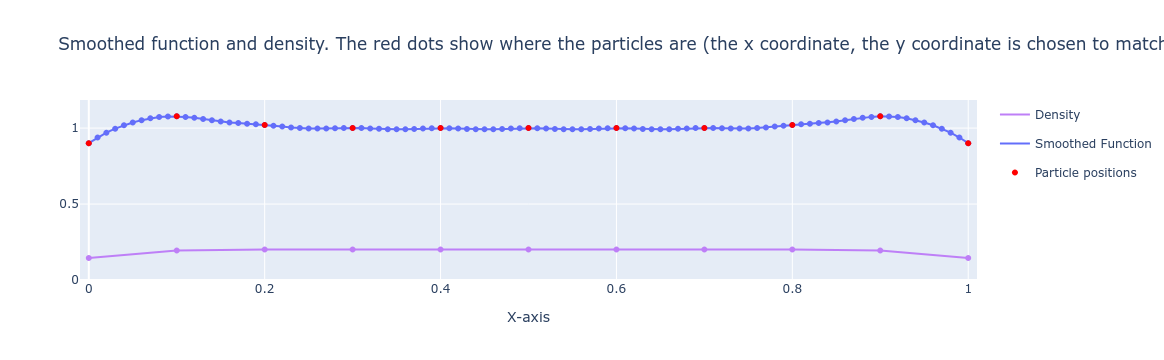

h = 0.15, mass = 0.02, m/dens = 0.09959016393442627


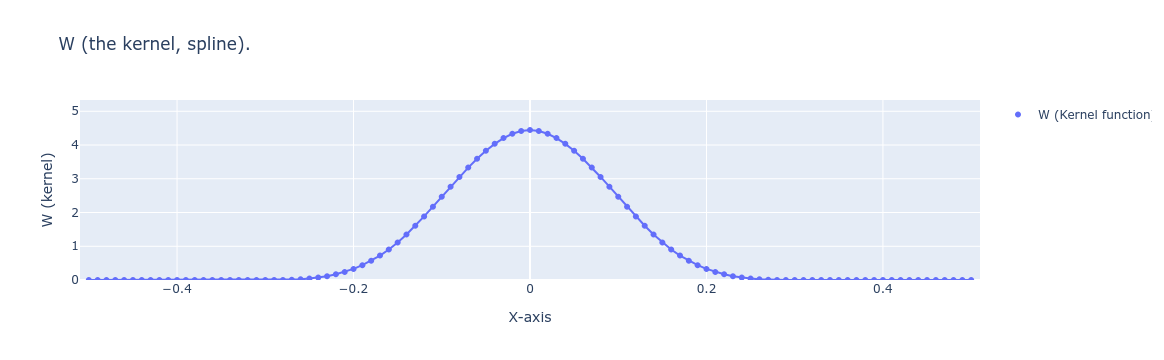

In [4]:
plot_spline_info(1.5, 'uniform', 101)

Not quite sure what is happening on the ends, I'll have to come back to it later. Probably not significant in practice since the density goes to 0 for many simulations. 
It probably comes because we have no particles past the end and so we only get half of the weight function.

Now try with a narrow spline (h = 0.5*grid space.)

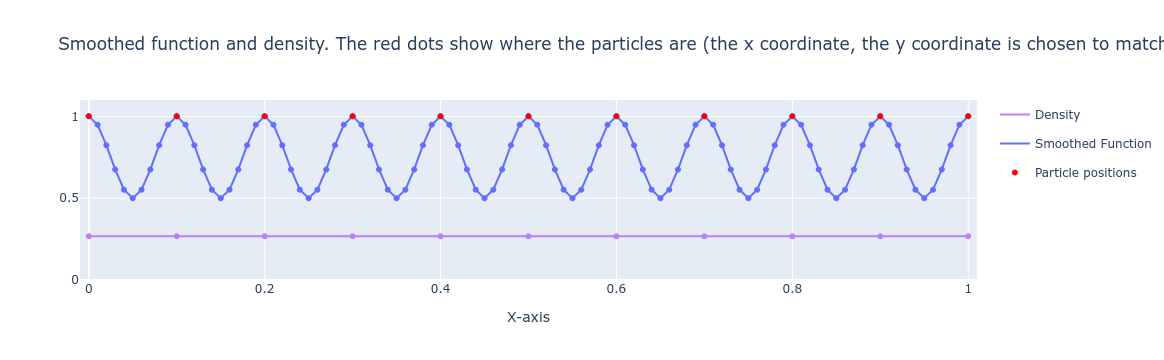

h = 0.05, mass = 0.02, m/dens = 0.075


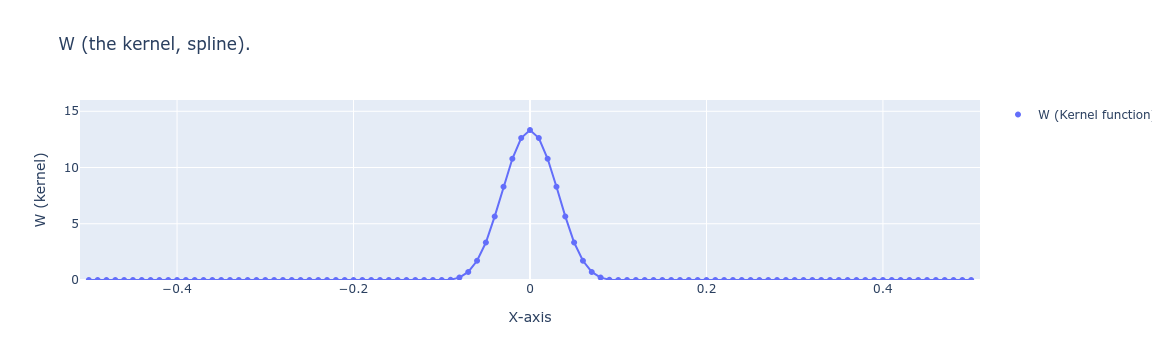

In [5]:
plot_spline_info(0.5, 'uniform', 101)

Now try the "medium" width spline:

In [6]:
plot_spline_info(0.8, 'uniform', 51)

h = 0.08, mass = 0.02, m/dens = 0.09909677419354841


Now we'll try the same graphs, but with a smoothed sin(r) function

In [7]:
plot_spline_info(1.5, 'sin', 21)

h = 0.15, mass = 0.02, m/dens = 0.09959016393442627


That went quite well, now make it intersting with a narrow spline.

In [8]:
plot_spline_info(0.5, 'sin', 101)

h = 0.05, mass = 0.02, m/dens = 0.075


Now try a "medium" width spline:

In [9]:
plot_spline_info(0.8, 'sin', 101)

h = 0.08, mass = 0.02, m/dens = 0.09909677419354841


### b) Derivatives
The other magical part of SPH is that derivatives are transferred from the function to the kernel:<br>
$ (5) \hspace{2cm} \begin{aligned}
\nabla_s f(\textbf{r}) = \int_\Omega \nabla f(\textbf{r}') W(\textbf{r}-\textbf{r}', h) d\textbf{r}'
\end{aligned}$
<br>
Integrating by parts gives:<br>
$ (6) \hspace{2cm} \begin{aligned}
\nabla_s f(\textbf{r}) =  \int_{\partial \Omega} f(\textbf{r}') W(\textbf{r}-\textbf{r}',h) \cdot \textbf{n} da + \int_\Omega f(\textbf{r}') \nabla W(\textbf{r}-\textbf{r}',h) d\textbf{r}'
\end{aligned}$<br>
Typically either $f$ or $W$ goes to 0 at large r, if not, the surface term can be used to create boundary conditions. That sounds like it would be terrible in practice.

So now we can use the "normal" smoothing procedure to obtain:<br>
$ (7) \hspace{2cm} \begin{aligned}
\nabla_s f(\textbf{r}) \approx \sum_j^N \frac{m_j}{\rho_j(\textbf{r}_j)} f(\textbf{r}_j) \nabla W(\textbf{r}-\textbf{r}_j,h)
\end{aligned}$ <br>
So now we have functions and derivatives so we can find the equations of motion for our system.

----------- Bate describes a fair bit of work from here that I need to look at in depth, Springel 2010 used the Lagrangian to derive all of the equations of motion. I also need to look at that more carefully.


## 3. Other Meshless Codes (GIZMO)
Gaburov and Nitadori (2011) describe a weighted particle meshless MHD code that looks very interesting. The ideas were used by Hopkins (2015) for his GIZMO code. Since it is available, I will be using it to run some experiments.
### a) Basic ideas and questions to guide study
The formalism seems similar to SPH, somewhere in the details there seem to be significant differences that I need to find. They (Gaburov/Hopkins) use a weak formulation with its attendant Riemann problem. That looks good because it handles discontinuities without added diffusion. The formalism looks a lot like SPH. They use a smoothing kernel. Gaburov says they use a cubic spline. But then Hopkins show this image:<br>

<img src="data/HopkinsDiscretization.resized.png" alt="Figure 1">

I'm confused. GIZMO doesn't look like the spherically symmetric splines we plotted above (and that Hopkins plotted). How does Hopkins fill the volume? So the next step will be to understand the discretization being used by Gaburov/Hopkins.

### b) The equations
Let's look at the equations to see if we can tell what is happening.

Following Gaburov:<br>
We attempt to solve<br>
$ (8) \hspace{2cm} \begin{aligned}
\frac{\partial u}{\partial t} + \nabla \cdot (\textbf{F} + \textbf{a}u) = S
\end{aligned}$<br>
We will use a weak solution (muliply by arbitrary $\phi$ and integrate) to get:<br>
$ (9) \hspace{2cm} \begin{aligned}
\int [u(\textbf{x},t)\dot{\phi} + \textbf{F}(u, \textbf{x}, t)\cdot \nabla \phi + S(\textbf{x},y)\phi] d\textbf{x} dt
\end{aligned}$<br>
where $\dot{\phi}$ is the convective derivative: $\dot{\phi} = \partial \phi / \partial t + \textbf{a}(\textbf{x},t) \cdot \nabla \phi$
... <br>
Gaburov has much more math, but it eventually boils down to this equation (from Hopkins 2015):<br>
$ (10) \hspace{2cm} \begin{aligned}
\frac{\text{d}}{\text{d}t}(V_i)\textbf{U}_i + \sum_j \tilde{\textbf{F}}\cdot \textbf{A}_{ij} = 0
\end{aligned}$<br>
In the paragraphs that follow Hopkins says that we should recognize that equation as a Godunov-type finite volume equation. The difference here is that the volume/face is defined by the actual volume integral defined by the weighting function.

So in SPH, the weighting function defines the smoothed properties of our particle and along with the gradient of the smoothing function this allows us to move the particles in a Lagrangian fashion. GIZMO on the other hand uses the "smoothing" function to provide the volumes for a finite volume method. There are many details that I need to understand, but at least now I have the starting of an intuitive understanding. 

........................................ <br>
To see if I was understanding correctly, I asked google "compare and contrast sph vs mfv simulation" to which it replied:<br>
Core Mathematical Formulation<br>
SPH: Approximates spatial derivatives directly using the gradient of a smoothing kernel function (∇ W). It computes pressure via an equation of state (weakly compressible or incompressible) and relies on manually tuned artificial viscosity to handle shocks.<br>
MFV: Does not take the gradient of the kernel function. Instead, it treats particles as representatives of an integrated volume, dynamically building effective faces between neighboring particles and calculating fluxes using a Godunov-type Riemann solver.<br>
Convergence and Accuracy<br>
SPH: Suffers from "particle noise" and lacks proper mathematical convergence at a fixed number of neighbors. It often smears out sharp shocks and contact discontinuities unless heavily patched.<br>
MFV: Exhibits proper mathematical convergence at a fixed neighbor count, provides dramatically sharper shock-capturing, and significantly reduces numerical diffusion and particle-clumping noise.<br>
Conservation and Artifacts<br>
SPH: Conserves mass, linear momentum, and energy natively, but struggles with fluid-mixing instabilities and artificial over-mixing or under-mixing.<br>
MFV: Maintains exact conservation of mass, momentum, and energy while handling fluid-mixing instabilities much more accurately without requiring tuned artificial dissipation terms. <br>
........................................ 

So it seems that I am on the right track.

That google search also lead me to Rosswog 2026 which has a review of SPH. In it it is stated that even though MFV solves the Riemann problem and so should handle shocks better, many modern SPH codes can do as well. It is a long review article that is only on ArXiv (it is an update of Rosswog 2015 which is published) and it seems to have valuable information.

----------- I need to undesrtand the Riemann problem and Finite Volumes in depth so that I can understand how they are implemented in Gaburov and in Hopkins. And I need to understand modern SPH/Rosswog

### b2) Reproducing Hopkins Figure 1
Before diving into the details of the implementation, I will try to reproduce the Figure 1 above. So we can plot the weighting functions to see if they match the description given.

Gaburov/Hopkins uses a partition function to divide the volumes among the particles:<br>
$ (11) \hspace{2cm} \begin{aligned}
\psi_i(\textbf{x})\equiv \frac{1}{\omega(\textbf{x})} W(\textbf{x} - \textbf{x}_i, h(\textbf{x}))
\end{aligned}$

$ (12) \hspace{2cm} \begin{aligned}
\omega(\textbf{x}) \equiv \sum_j W(\textbf{x} - \textbf{x}_i, h(\textbf{x}))
\end{aligned}$

$\omega(\textbf{x})$ is very similar to density (our eq. 3), except that is is calculated at an arbitrary $x$ and not just at the particle positions. $\psi$ is the fraction of the volume that is associated with a given particle at a given point in space. Which sounds similar to the probability definition of the weighting function from Lucy.

We have:<br>
$ (13) \hspace{2cm} \begin{aligned}
1 = \sum_i \psi_i(\textbf{x})
\end{aligned}$ <br>
and <br>
$ (14) \hspace{2cm} \begin{aligned}
V_i = \int \psi_i(\textbf{x}) \text{d}\textbf{x}
\end{aligned}$ <br>
with $V_i$ being the effective volume of particle $i$.

So now we can plot $\psi_i(\textbf{x})$ to see if it looks like Hopkins figure 1. To keep it simple, I'll work in 1-d, but we should be able to see what is happening.

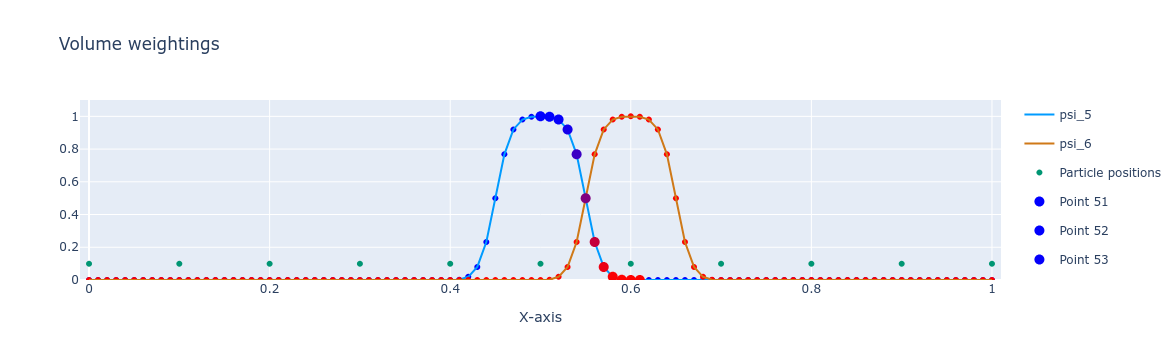

V_5 = 0.09998941219432883, 1.0/omega[0.5] = 0.07499437542184337
h = 0.05, sum(kernel) = 1.0, omega*h (Nngb) = 0.6667166666666666


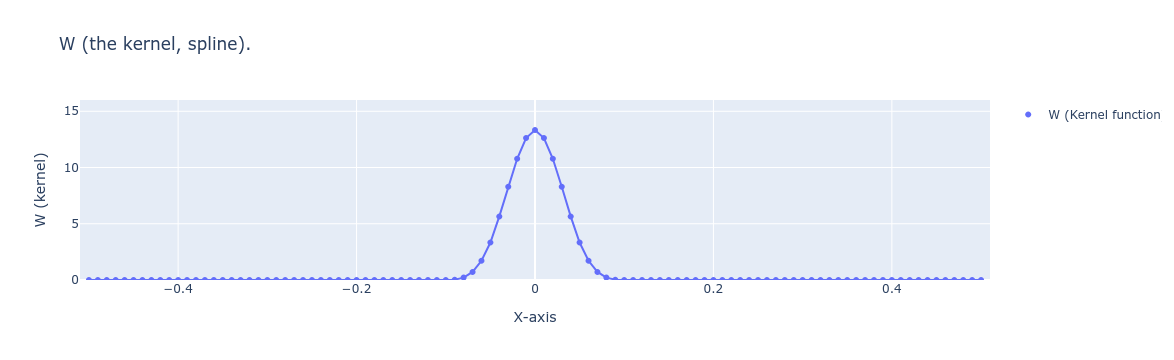

In [10]:
plot_psi(0.5, 101, 5)

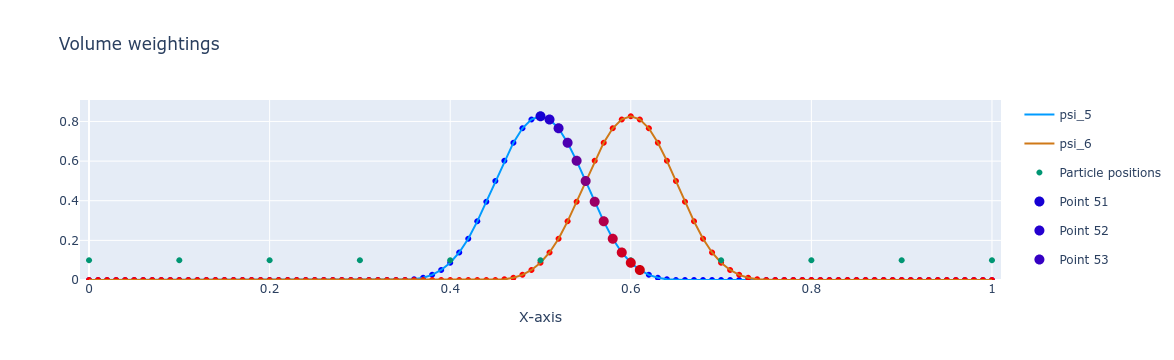

V_5 = 0.099990000787121, 1.0/omega[0.5] = 0.09908695499594364
h = 0.08, sum(kernel) = 1.0, omega*h (Nngb) = 0.8073716666666666


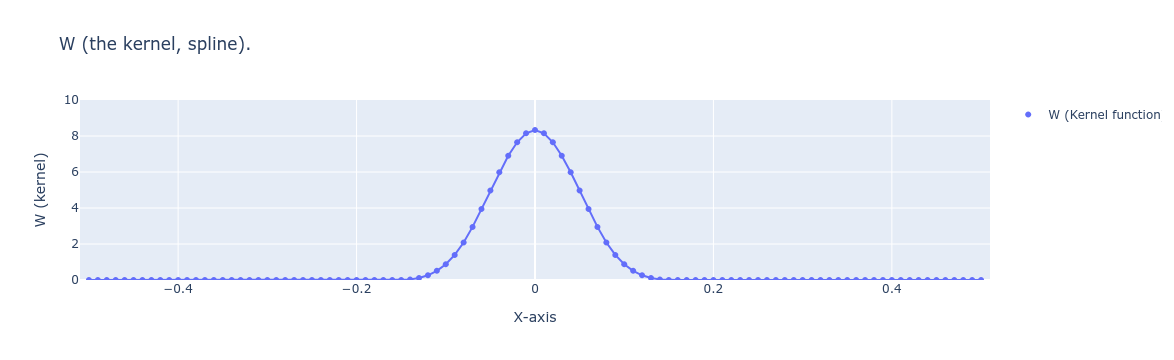

In [11]:
plot_psi(0.8, 101, 5)

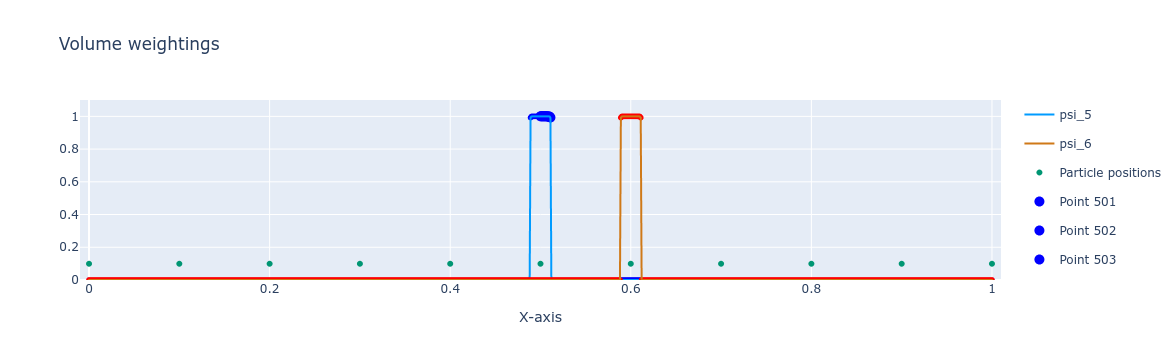

V_5 = 0.022981458741416938, 1.0/omega[0.5] = 0.008999919000728994
h = 0.006, sum(kernel) = 0.9999999999999999, omega*h (Nngb) = 0.6666726666666667


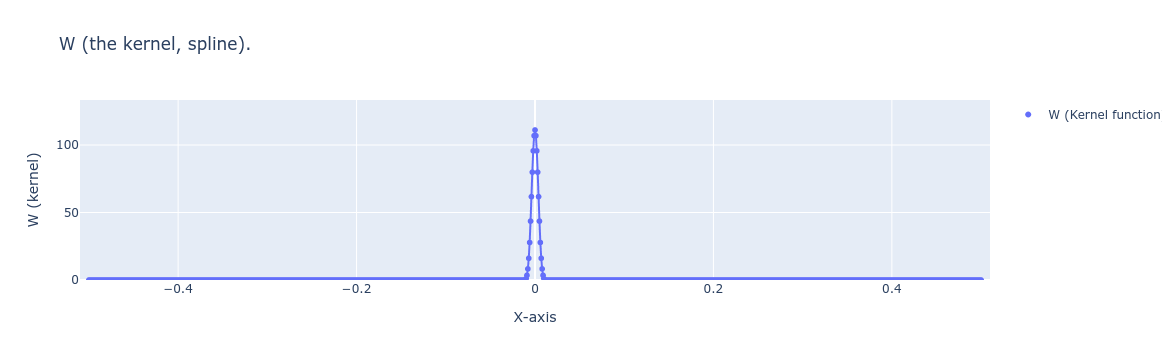

In [12]:
plot_psi(0.06, 1001, 5)

The larger dots with the color gradients are an attempt to reproduce the ideas in Hopkins Fig 1. Using h = 0.8 (*distance between particles) gives reasonable results. It appears that we get something like figure 1, but it still seems to not be quite as steep at the edges. Perhaps 2-d would be a bit different? And $h$ needs to be large enough to have overlap between particles. Hopkins seems to say that as W approaches a delta function, we get moving mesh, but those last results don't seem to agree. Did I do something wrong, since the volume has decreased? He does say that 100% of the weight will be associated with the nearest particles which is clearly happening. And I guess that that is what Fig 1 is showing for the middle graph.<br>
Also, Gaburov says that they use $1/\omega$ as a good approximation to $V$. For h > 0.8 that seems to be a pretty good approximation.

### c) Finite Volumes
The basic idea of finite volumes is quite simple. Divide the region into volumes, find the flux of quantities through the face of the volumes and use that flux to update the quantities. In our case, we move the particles in a lagrangian fashion but the fluxes still determine/update the properties of the particles. Over the next few weeks, I will look in detail at how finite volumes are implemented in a meshless code.

### d) The Riemann Problem
The Riemann problem starts with a fluid at two (different) states. It solves the equations for the interface between them. In the current problem, we have quantities in adjoing cells and we want to know the flux between them. The Riemann problem gives us the fluxes. This should be an interesting exploration.

### e) Rosswog

## 4. Some example runs
Some examples of running GIZMO (or other) codes.

### a) GIZMO sample "Evrard"
The gizmo code has a number of sample simulations. This is "Evrard" from Hopkins 2015. They say:<br>
"The gas is initially at rest and has thermal energy per unit
mass u = 0.05 (much less than the gravitational binding energy).
When the simulation begins, the gas free-falls towards r = 0 under self-gravity, until a strong shock occurs and the inner regions
‘bounce’ back, sending the shock outwards through the infalling
outer regions of the sphere"<br>

The video was created in Visit. It simply shows the positions of the particles with time. Although the axes change with time, the actual visible scale stays the same. Still need to figure out how to set the scale and have it not change.

If the controls for the video don't appear, right click should give you a "play" option.<br>

In [13]:
from IPython.display import Video

Video("data/Evrard_movie.mp4", width=600, html_attributes="controls", embed = False)

## 5. Formation theory
Look at "An Introduction to Star Formation"  Ward-Thompson and also "Star Formation" Krumholz. Notes and problem solutions to go here...

## 6. References
1] Matthew Russell. Bate and University of Cambridge. Institute of Astron-
omy. The role of accretion in binary star formation / by Matthew Russell
Bate. eng. Cambridge, 1995.<br>
[2] Evghenii Gaburov and Keigo Nitadori. “Astrophysical weighted particle
magnetohydrodynamics”. en. In: Mon. Not. R. Astron. Soc. 414.1 (June
2011), pp. 129–154.<br>
[3] R A Gingold and J J Monaghan. “Kernel estimates as a basis for general
particle methods in hydrodynamics”. en. In: J. Comput. Phys. 46.3 (June
1982), pp. 429–453.<br>
[4] R A Gingold and J J Monaghan. “Smoothed particle hydrodynamics:
theory and application to non-spherical stars”. In: Mon. Not. R. Astron.
Soc. 181.3 (Dec. 1977), pp. 375–389.<br>
[5] Philip F Hopkins. “A new class of accurate, mesh-free hydrodynamic sim-
ulation methods”. en. In: Mon. Not. R. Astron. Soc. 450.1 (June 2015),
pp. 53–110.<br>
[6] Philip F Hopkins and Matthias J Raives. “Accurate, meshless methods for
magnetohydrodynamics”. en. In: Mon. Not. R. Astron. Soc. 455.1 (Jan.
2016), pp. 51–88.<br>
[7] L B Lucy. “A numerical approach to the testing of the fission hypothesis”.
In: Astron. J. 82 (Dec. 1977), p. 1013.<br>
[8] Stephan Rosswog. “SPH methods in the modelling of compact objects”.
en. In: Living Rev. Comput. Astrophys. 1.1 (Dec. 2015).<br>
[9] Stephan Rosswog. “SPH methods in the modelling of compact objects”.
In: (July 2026). arXiv: 2607.14828 [astro-ph.HE]<br>
[10] Volker Springel. “Smoothed particle hydrodynamics in astrophysics”. en.
In: Annu. Rev. Astron. Astrophys. 48.1 (Aug. 2010), pp. 391–430